# Visualización de Perfiles de Calidad - Capa Silver

## Descripción

Este notebook visualiza los resultados del **profiling inicial** generado previamente para los datasets del **NYC Taxi & Limousine Commission (TLC)**.

A partir de los perfiles almacenados en formato **JSON**, se presentan métricas e indicadores de calidad correspondientes a los datos de la **capa Bronze** para el período **2023–2025**, facilitando su análisis e interpretación antes del procesamiento hacia la **capa Silver**.

---

## Objetivos

- Visualizar la calidad de los datos para cada tipo de servicio.
- Identificar problemas de completitud y calidad por columna.
- Comparar la evolución temporal del volumen y los indicadores de calidad.
- Generar visualizaciones que apoyen el análisis y la presentación de resultados.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Origen** | Perfiles de calidad generados por `profiling_inicial.py`. |
| **Ubicación** | `data/silver/profiling_inicial/_profiles/` |
| **Cobertura temporal** | 2023, 2024 y 2025. |
| **Datasets** | Yellow Taxi, Green Taxi, FHV, FHVHV y Taxi Zone Lookup. |

In [21]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colores institucionales
COLORS = {
    'yellow': '#F7DC6F',
    'green': '#82E0AA',
    'fhv': '#85C1E9',
    'fhvhv': '#ABB2B9',
    'lookup': '#D7BDE2',
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#6A994E',
    'danger': '#C73E1D',
    'excluded': '#95A5A6'
}

# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
PROFILE_DIR = ROOT_DIR / "data" / "silver" / "profiling_inicial" / "_profiles"

print("=" * 80)
print(" VISUALIZACIÓN - PROFILING INICIAL")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Perfiles: {PROFILE_DIR}")

if not PROFILE_DIR.exists():
    print("\n ERROR: No se encontraron perfiles.")
    print("   Ejecuta primero: 01_profiling_inicial.py")
    exit()

 VISUALIZACIÓN - PROFILING INICIAL
 Fecha: 2026-07-17 01:05:45
 Perfiles: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles


In [27]:
# ============================================================
# FUNCIONES DE CARGA DE PERFILES
# ============================================================

YEARS = [2023, 2024, 2025]
TAXI_TYPES = ['yellow', 'green', 'fhv', 'fhvhv']
EXCLUDED_TYPES = ['fhvhv']  # Excluido por volumen masivo

def load_profile(taxi_type, year):
    """Carga un perfil JSON para un tipo y año específico"""
    if taxi_type == "lookup":
        path = PROFILE_DIR / taxi_type / "lookup_profile.json"
    else:
        path = PROFILE_DIR / taxi_type / f"{taxi_type}_{year}_profile.json"
    
    if not path.exists():
        return None
    
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_profiles():
    """Carga todos los perfiles disponibles para 2023-2025"""
    profiles = {}
    
    for taxi_type in TAXI_TYPES:
        profiles[taxi_type] = {}
        for year in YEARS:
            profile = load_profile(taxi_type, year)
            if profile:
                profiles[taxi_type][year] = profile
    
    # Cargar lookup
    lookup = load_profile("lookup", None)
    if lookup:
        profiles['lookup'] = lookup
    
    return profiles

# Cargar todos los perfiles
print(" Cargando perfiles...")
ALL_PROFILES = load_all_profiles()

# Estadísticas de carga - CORREGIDO: usar ALL_PROFILES en lugar de profiles
total_profiles = 0
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_PROFILES and isinstance(ALL_PROFILES[taxi_type], dict):
        total_profiles += len(ALL_PROFILES[taxi_type])

print(f" Perfiles cargados: {total_profiles}")

# Mostrar disponibilidad
print("\n Disponibilidad de perfiles:")
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_PROFILES:
        years_found = list(ALL_PROFILES[taxi_type].keys())
        status = "" if years_found else "❌"
        excluded = " " if taxi_type in EXCLUDED_TYPES else ""
        print(f"   {status} {taxi_type.upper()}{excluded}: {years_found if years_found else 'Sin datos'}")

# Mostrar lookup
if 'lookup' in ALL_PROFILES:
    print(f"    LOOKUP: Disponible")
else:
    print(f"    LOOKUP: No disponible")

 Cargando perfiles...
 Perfiles cargados: 12

 Disponibilidad de perfiles:
    YELLOW: [2023, 2024, 2025]
    GREEN: [2023, 2024, 2025]
    FHV: [2023, 2024, 2025]
    FHVHV : [2023, 2024, 2025]
    LOOKUP: Disponible


 1. RESUMEN GENERAL DE PERFILES (2023-2025)

📋 Tabla Resumen:
  Tipo  Años  Meses  Registros (M)  Calidad (%)    Estado
 FHVHV     3     36         715.55        96.39  EXCLUIDO
YELLOW     3     36         128.20        96.67  INCLUIDO
   FHV     3     36          58.54        88.50  INCLUIDO
 GREEN     3     36           2.04        95.00  INCLUIDO


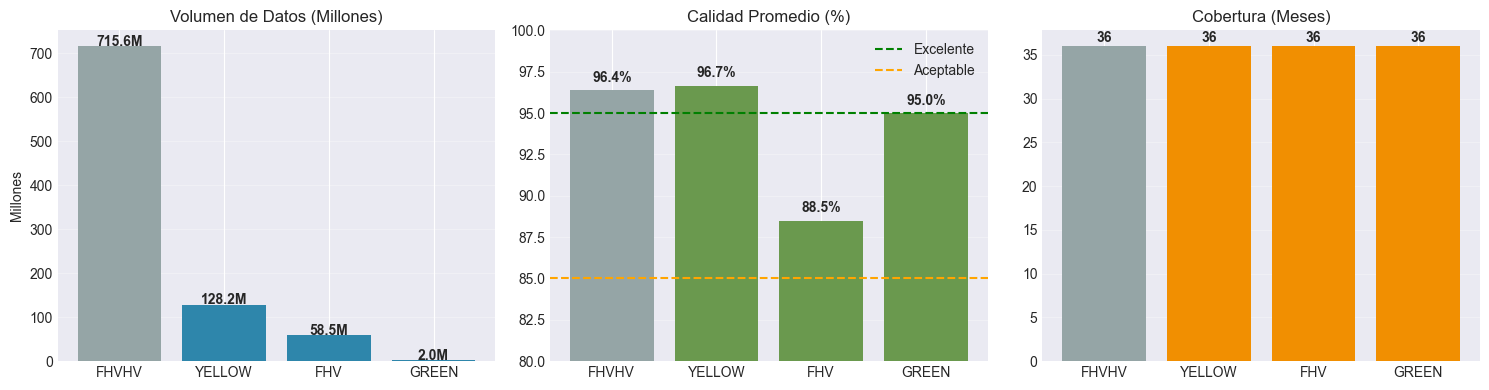


💡 CONCLUSIONES:
   • Total registros analizados: 904.3M
   • Calidad promedio: 94.1%


In [38]:
# ============================================================
# 1. RESUMEN GENERAL DE PERFILES
# ============================================================

print("=" * 80)
print(" 1. RESUMEN GENERAL DE PERFILES (2023-2025)")
print("=" * 80)

# Crear DataFrame resumen
summary_data = []
for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_PROFILES:
        continue
    
    type_profiles = ALL_PROFILES[taxi_type]
    total_records = 0
    quality_scores = []
    months_total = 0
    
    for year, profile in type_profiles.items():
        total_records += profile.get('total_records', 0)
        quality_scores.append(profile.get('quality_score', 0))
        months_total += len(profile.get('months_processed', []))
    
    if total_records > 0:
        is_excluded = taxi_type in EXCLUDED_TYPES
        summary_data.append({
            'Tipo': taxi_type.upper(),
            'Años': len(type_profiles),
            'Meses': months_total,
            'Registros (M)': total_records / 1_000_000,
            'Calidad (%)': np.mean(quality_scores),
            'Estado': ' EXCLUIDO' if is_excluded else ' INCLUIDO'
        })

df_summary = pd.DataFrame(summary_data).sort_values('Registros (M)', ascending=False)

print("\n📋 Tabla Resumen:")
print(df_summary.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Volumen por tipo
colors = [COLORS['excluded'] if 'EXCLUIDO' in row['Estado'] else COLORS['primary'] 
          for _, row in df_summary.iterrows()]
bars = axes[0].bar(df_summary['Tipo'], df_summary['Registros (M)'], color=colors)
axes[0].set_title('Volumen de Datos (Millones)')
axes[0].set_ylabel('Millones')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_summary['Registros (M)']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
                f'{val:.1f}M', ha='center', fontweight='bold')

# Gráfico 2: Calidad por tipo
colors2 = [COLORS['excluded'] if 'EXCLUIDO' in row['Estado'] else COLORS['success'] 
           for _, row in df_summary.iterrows()]
bars = axes[1].bar(df_summary['Tipo'], df_summary['Calidad (%)'], color=colors2)
axes[1].axhline(y=95, color='green', linestyle='--', label='Excelente')
axes[1].axhline(y=85, color='orange', linestyle='--', label='Aceptable')
axes[1].set_title('Calidad Promedio (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(80, 100)
for bar, val in zip(bars, df_summary['Calidad (%)']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
                f'{val:.1f}%', ha='center', fontweight='bold')

# Gráfico 3: Cobertura temporal
colors3 = [COLORS['excluded'] if 'EXCLUIDO' in row['Estado'] else COLORS['accent'] 
           for _, row in df_summary.iterrows()]
bars = axes[2].bar(df_summary['Tipo'], df_summary['Meses'], color=colors3)
axes[2].set_title('Cobertura (Meses)')
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_summary['Meses']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, 
                f'{val}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
print(f"   • Total registros analizados: {df_summary['Registros (M)'].sum():.1f}M")
print(f"   • Calidad promedio: {df_summary['Calidad (%)'].mean():.1f}%")


 2. ANÁLISIS DE TABLA LOOKUP (ZONAS)

 ESTADÍSTICAS:
   • Total de zonas: 265
   • Calidad general: 100.0%
   • Columnas: 4

 Detalle por columna:
     Columna   Tipo  Nulos %  Distintos
  LocationID    int     0.00        265
     Borough string     0.00          8
        Zone string     0.00        262
service_zone string     0.00          5


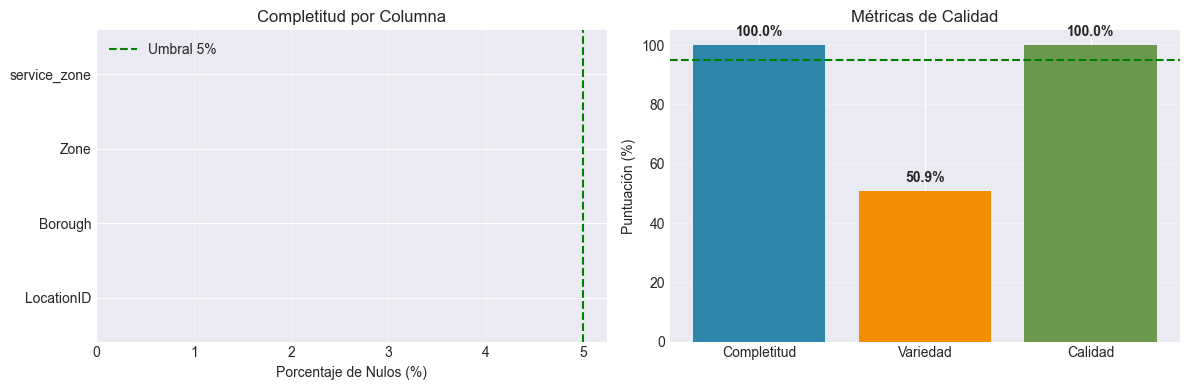

 CONCLUSIÓN: Tabla de zonas en perfecto estado (0% nulos)


In [39]:
# ============================================================
# 2. ANÁLISIS DE TABLA LOOKUP (ZONAS)
# ============================================================

print("=" * 80)
print(" 2. ANÁLISIS DE TABLA LOOKUP (ZONAS)")
print("=" * 80)

lookup = ALL_PROFILES.get('lookup')

if lookup:
    print(f"""
 ESTADÍSTICAS:
   • Total de zonas: {lookup.get('total_records', 0):,}
   • Calidad general: {lookup.get('quality_score', 0):.1f}%
   • Columnas: {len(lookup.get('columns', {}))}
""")
    
    # Crear DataFrame de columnas
    columns_data = []
    for col_name, col_info in lookup.get('columns', {}).items():
        columns_data.append({
            'Columna': col_name,
            'Tipo': col_info.get('data_type', 'unknown'),
            'Nulos %': col_info.get('null_pct', 0),
            'Distintos': col_info.get('distinct_count', 0)
        })
    
    df_lookup = pd.DataFrame(columns_data)
    
    print(" Detalle por columna:")
    print(df_lookup.to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico 1: Nulos por columna
    ax1 = axes[0]
    colors = ['#2E86AB' if x == 0 else '#C73E1D' for x in df_lookup['Nulos %']]
    bars = ax1.barh(df_lookup['Columna'], df_lookup['Nulos %'], color=colors)
    ax1.set_xlabel('Porcentaje de Nulos (%)')
    ax1.set_title('Completitud por Columna')
    ax1.axvline(x=5, color='green', linestyle='--', label='Umbral 5%')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Gráfico 2: Métricas de calidad
    ax2 = axes[1]
    metrics = ['Completitud', 'Variedad', 'Calidad']
    values = [
        100 - df_lookup['Nulos %'].mean(),
        df_lookup['Distintos'].mean() / lookup.get('total_records', 1) * 100,
        lookup.get('quality_score', 0)
    ]
    bars = ax2.bar(metrics, values, color=['#2E86AB', '#F18F01', '#6A994E'])
    ax2.set_ylabel('Puntuación (%)')
    ax2.set_title('Métricas de Calidad')
    ax2.axhline(y=95, color='green', linestyle='--')
    ax2.set_ylim(0, 105)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(" CONCLUSIÓN: Tabla de zonas en perfecto estado (0% nulos)")
else:
    print(" Perfil de lookup no disponible")

 3. EVOLUCIÓN TEMPORAL POR TIPO (2023-2025)

 YELLOW  - Evolución:
 Año  Registros (M)  Calidad (%)  Meses
2023          38.31       100.00     12
2024          41.17       100.00     12
2025          48.72        90.00     12


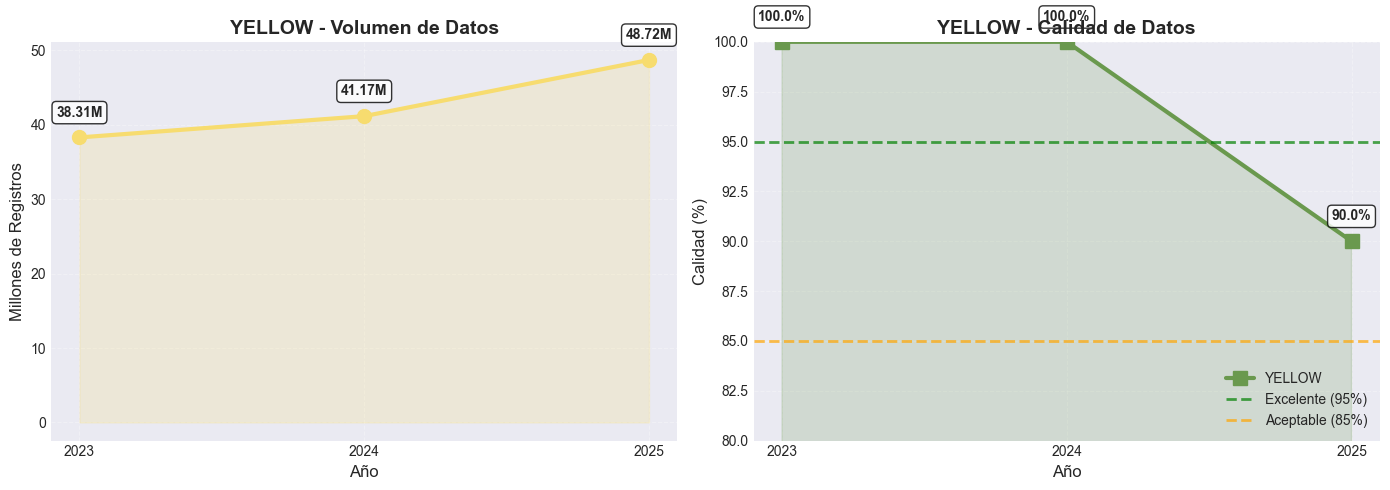


 YELLOW - Tendencias:
   • Volumen: 38.3M → 48.7M (+27.2%)
   • Calidad: 100.0% → 90.0% (-10.0%)

 GREEN  - Evolución:
 Año  Registros (M)  Calidad (%)  Meses
2023           0.79        95.00     12
2024           0.66        95.00     12
2025           0.59        95.00     12


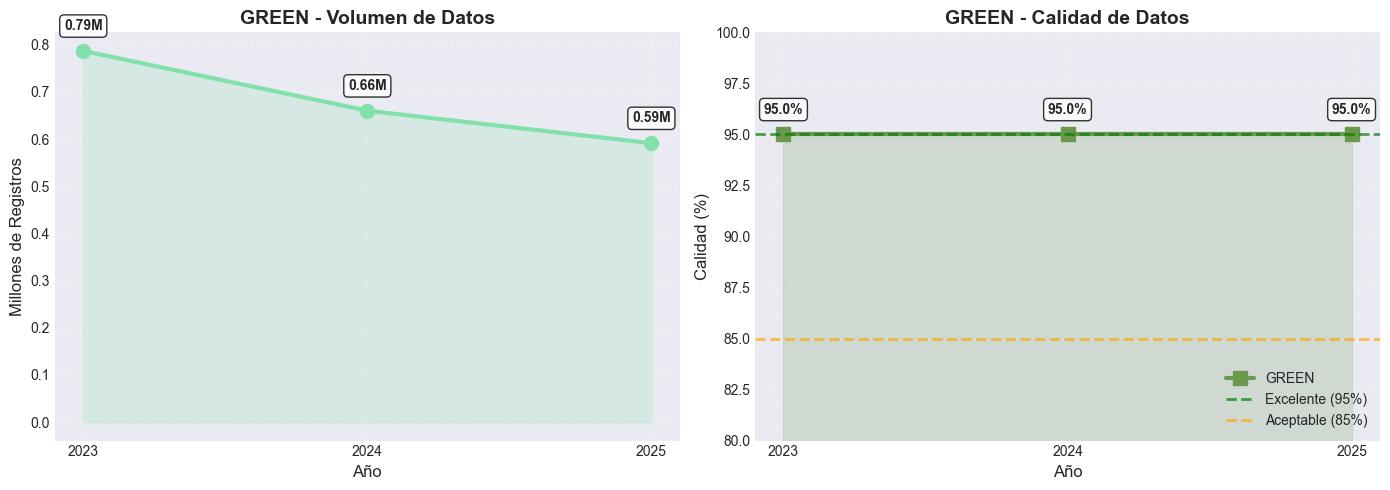


 GREEN - Tendencias:
   • Volumen: 0.8M → 0.6M (-24.9%)
   • Calidad: 95.0% → 95.0% (+0.0%)

 FHV  - Evolución:
 Año  Registros (M)  Calidad (%)  Meses
2023          15.86        88.50     12
2024          17.63        88.83     12
2025          25.05        88.17     12


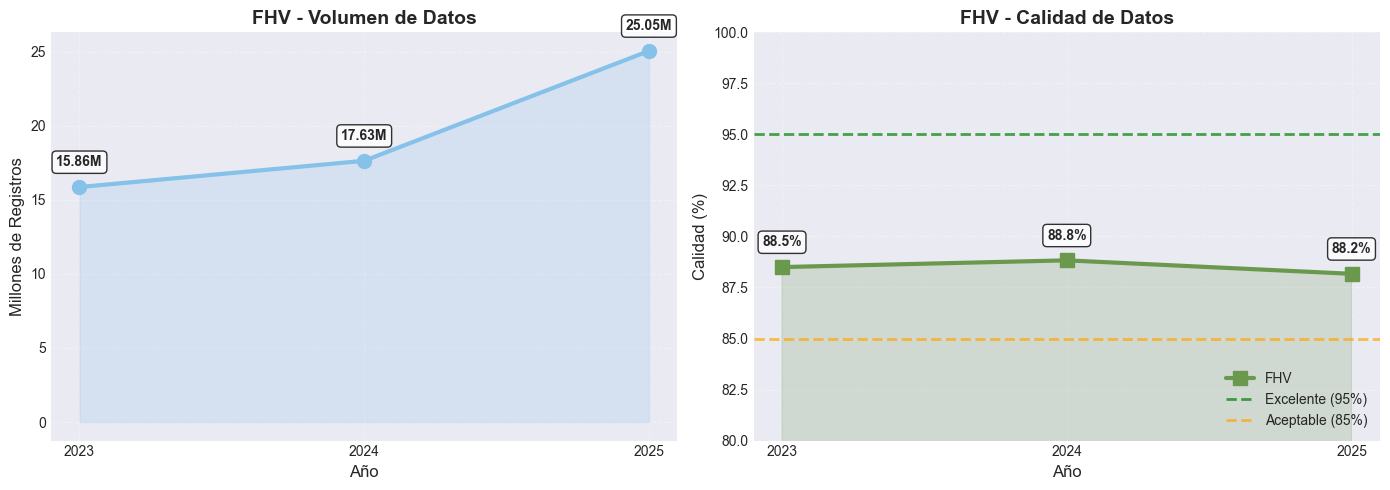


 FHV - Tendencias:
   • Volumen: 15.9M → 25.0M (+57.9%)
   • Calidad: 88.5% → 88.2% (-0.3%)

 FHVHV (EXCLUIDO) - Evolución:
 Año  Registros (M)  Calidad (%)  Meses
2023         232.49        95.50     12
2024         239.47        96.00     12
2025         243.59        97.67     12


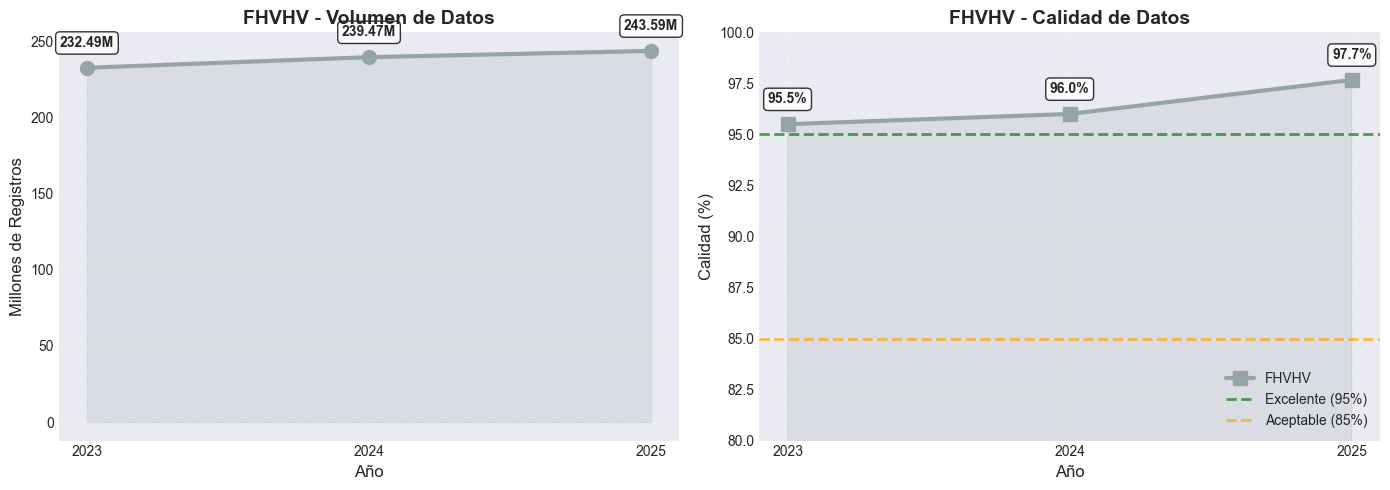


 FHVHV - Tendencias:
   • Volumen: 232.5M → 243.6M (+4.8%)
   • Calidad: 95.5% → 97.7% (+2.2%)


In [40]:
# ============================================================
# 3. EVOLUCIÓN TEMPORAL (2023-2025)
# ============================================================

print("=" * 80)
print(" 3. EVOLUCIÓN TEMPORAL POR TIPO (2023-2025)")
print("=" * 80)

# Incluir TODOS los tipos (incluyendo FHVHV)
active_types = TAXI_TYPES  # Ya no excluye fhvhv

for taxi_type in active_types:
    if taxi_type not in ALL_PROFILES:
        print(f" {taxi_type.upper()}: Sin datos")
        continue
    
    type_profiles = ALL_PROFILES[taxi_type]
    
    # Preparar datos - ordenados por año
    data = []
    for year in sorted(YEARS):  # Asegurar orden cronológico
        if year in type_profiles:
            profile = type_profiles[year]
            data.append({
                'Año': year,
                'Registros (M)': profile.get('total_records', 0) / 1_000_000,
                'Calidad (%)': profile.get('quality_score', 0),
                'Meses': len(profile.get('months_processed', []))
            })
    
    if not data:
        print(f" {taxi_type.upper()}: Sin datos para los años especificados")
        continue
    
    df_year = pd.DataFrame(data)
    df_year = df_year.sort_values('Año')  # Ordenar por año
    
    # Determinar si está excluido
    is_excluded = taxi_type in EXCLUDED_TYPES
    tipo_label = f"{taxi_type.upper()} {'(EXCLUIDO)' if is_excluded else ''}"
    
    print(f"\n {tipo_label} - Evolución:")
    print(df_year.to_string(index=False))
    
    # Visualización - Gráficos mejorados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Color base según tipo
    base_color = COLORS.get(taxi_type, '#2E86AB')
    if is_excluded:
        base_color = COLORS['excluded']
    
    # ===== GRÁFICO 1: Volumen =====
    ax1 = axes[0]
    line1 = ax1.plot(df_year['Año'], df_year['Registros (M)'], 
                     marker='o', linewidth=3, markersize=10, 
                     color=base_color, label=f'{taxi_type.upper()}')
    
    # Rellenar área bajo la curva
    ax1.fill_between(df_year['Año'], df_year['Registros (M)'], 
                     alpha=0.2, color=base_color)
    
    ax1.set_title(f'{taxi_type.upper()} - Volumen de Datos', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Año', fontsize=12)
    ax1.set_ylabel('Millones de Registros', fontsize=12)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Añadir valores en los puntos
    for x, y in zip(df_year['Año'], df_year['Registros (M)']):
        ax1.annotate(f'{y:.2f}M', 
                    xy=(x, y),
                    xytext=(0, 15),
                    textcoords='offset points',
                    ha='center',
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Configurar eje X para mostrar todos los años
    ax1.set_xticks(YEARS)
    ax1.set_xticklabels(YEARS)
    
    # ===== GRÁFICO 2: Calidad =====
    ax2 = axes[1]
    color_calidad = COLORS['excluded'] if is_excluded else COLORS['success']
    
    line2 = ax2.plot(df_year['Año'], df_year['Calidad (%)'], 
                     marker='s', linewidth=3, markersize=10,
                     color=color_calidad, label=f'{taxi_type.upper()}')
    
    # Rellenar área bajo la curva
    ax2.fill_between(df_year['Año'], df_year['Calidad (%)'], 
                     alpha=0.2, color=color_calidad)
    
    ax2.set_title(f'{taxi_type.upper()} - Calidad de Datos', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Año', fontsize=12)
    ax2.set_ylabel('Calidad (%)', fontsize=12)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Líneas de referencia
    ax2.axhline(y=95, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Excelente (95%)')
    ax2.axhline(y=85, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Aceptable (85%)')
    
    # Añadir valores en los puntos
    for x, y in zip(df_year['Año'], df_year['Calidad (%)']):
        ax2.annotate(f'{y:.1f}%', 
                    xy=(x, y),
                    xytext=(0, 15),
                    textcoords='offset points',
                    ha='center',
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Configurar eje X para mostrar todos los años
    ax2.set_xticks(YEARS)
    ax2.set_xticklabels(YEARS)
    ax2.set_ylim(80, 100)  # Escala fija para mejor comparación
    ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar resumen de cambios
    if len(df_year) > 1:
        vol_ini = df_year['Registros (M)'].iloc[0]
        vol_fin = df_year['Registros (M)'].iloc[-1]
        vol_cambio = ((vol_fin - vol_ini) / vol_ini * 100) if vol_ini > 0 else 0
        
        cal_ini = df_year['Calidad (%)'].iloc[0]
        cal_fin = df_year['Calidad (%)'].iloc[-1]
        cal_cambio = cal_fin - cal_ini
        
        print(f"\n {taxi_type.upper()} - Tendencias:")
        print(f"   • Volumen: {vol_ini:.1f}M → {vol_fin:.1f}M ({vol_cambio:+.1f}%)")
        print(f"   • Calidad: {cal_ini:.1f}% → {cal_fin:.1f}% ({cal_cambio:+.1f}%)")

 4. ANALISIS DE COLUMNAS (Ultimo año disponible)

YELLOW 2025: 20 columnas (estructura: consolidated_columns)

  Top 5 columnas con mas nulos:
             Columna  Nulos %  Distintos
congestion_surcharge     2.39       4.08
     passenger_count     2.39       9.08
          RatecodeID     2.39       7.17
         Airport_fee     2.39       5.83
  store_and_fwd_flag     2.39       3.00


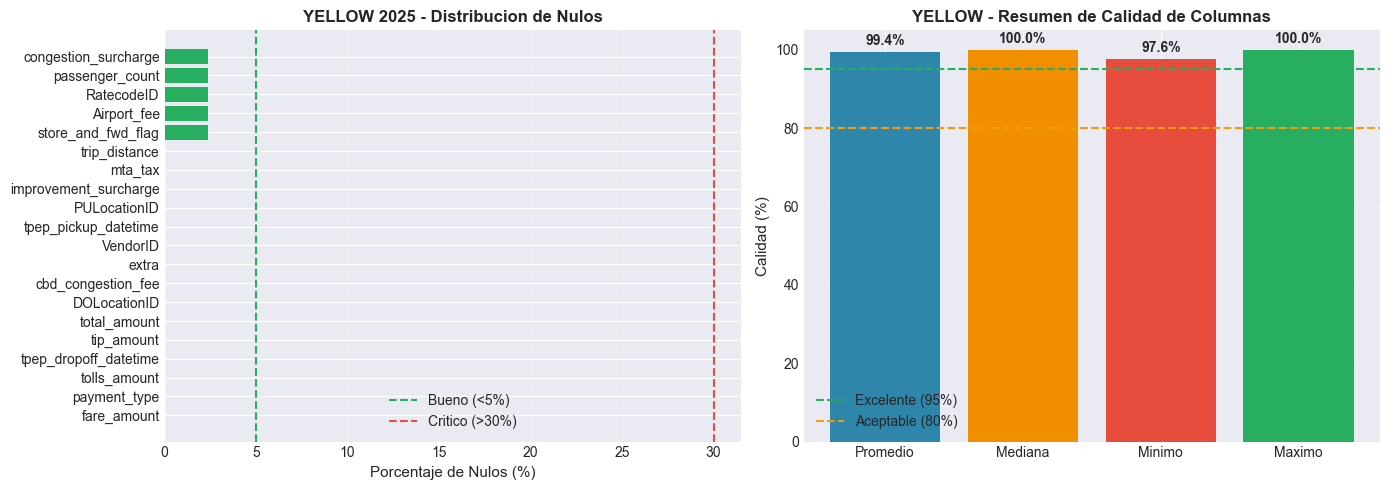


  Resumen de calidad de columnas:
    Promedio: 99.4%
    Mediana: 100.0%
    Minimo: 97.6%
    Maximo: 100.0%
    Columnas sin nulos: 15
    Columnas criticas (>30% nulos): 0

GREEN 2025: 21 columnas (estructura: consolidated_columns)

  Top 5 columnas con mas nulos:
             Columna  Nulos %  Distintos
           ehail_fee   100.00       1.00
           trip_type     8.44       3.00
congestion_surcharge     8.43       5.08
  store_and_fwd_flag     8.43       3.00
        payment_type     8.43       5.75


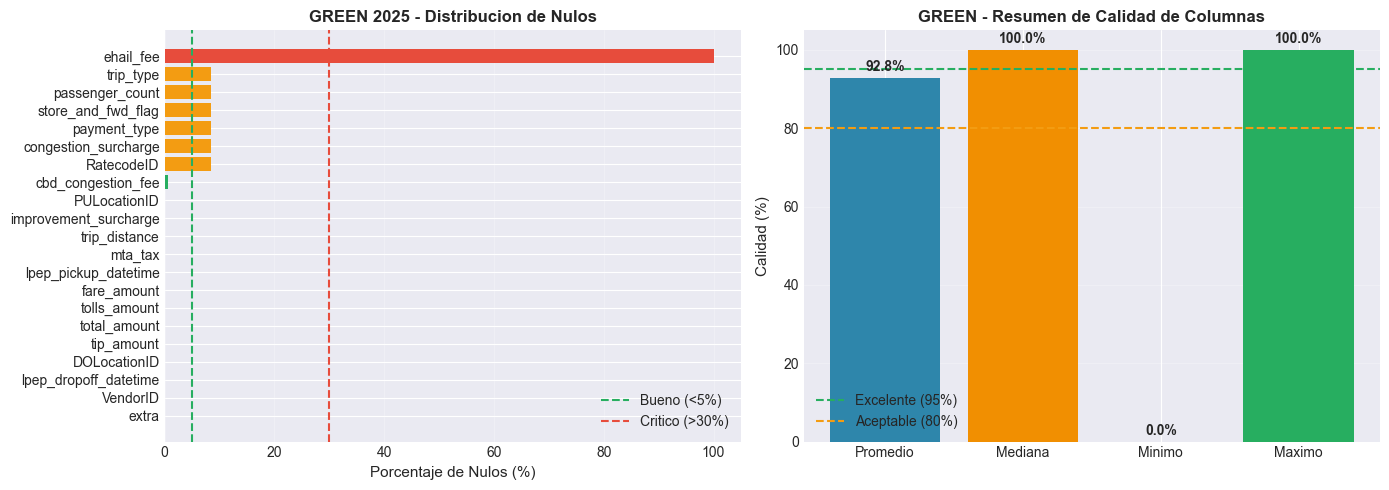


  Resumen de calidad de columnas:
    Promedio: 92.8%
    Mediana: 100.0%
    Minimo: 0.0%
    Maximo: 100.0%
    Columnas sin nulos: 13
    Columnas criticas (>30% nulos): 1

FHV 2025: 7 columnas (estructura: consolidated_columns)

  Top 5 columnas con mas nulos:
             Columna  Nulos %  Distintos
             SR_Flag     9.99       1.00
        PUlocationID     8.20     256.33
        DOlocationID     1.68     259.92
dispatching_base_num     0.00     355.25
    dropOff_datetime     0.00  194055.08


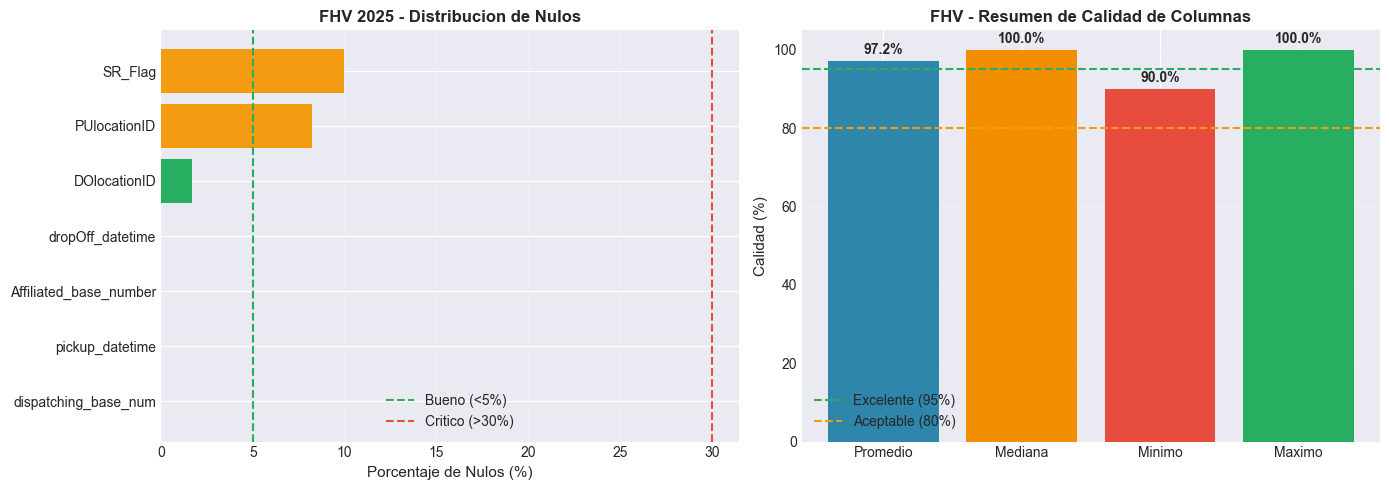


  Resumen de calidad de columnas:
    Promedio: 97.2%
    Mediana: 100.0%
    Minimo: 90.0%
    Maximo: 100.0%
    Columnas sin nulos: 4
    Columnas criticas (>30% nulos): 0

FHVHV 2025: 25 columnas (estructura: consolidated_columns)

  Top 5 columnas con mas nulos:
             Columna  Nulos %  Distintos
originating_base_num     2.77       4.67
   on_scene_datetime     0.45 1309972.58
 shared_request_flag     0.00       2.00
          trip_miles     0.00   32127.17
   shared_match_flag     0.00       2.00


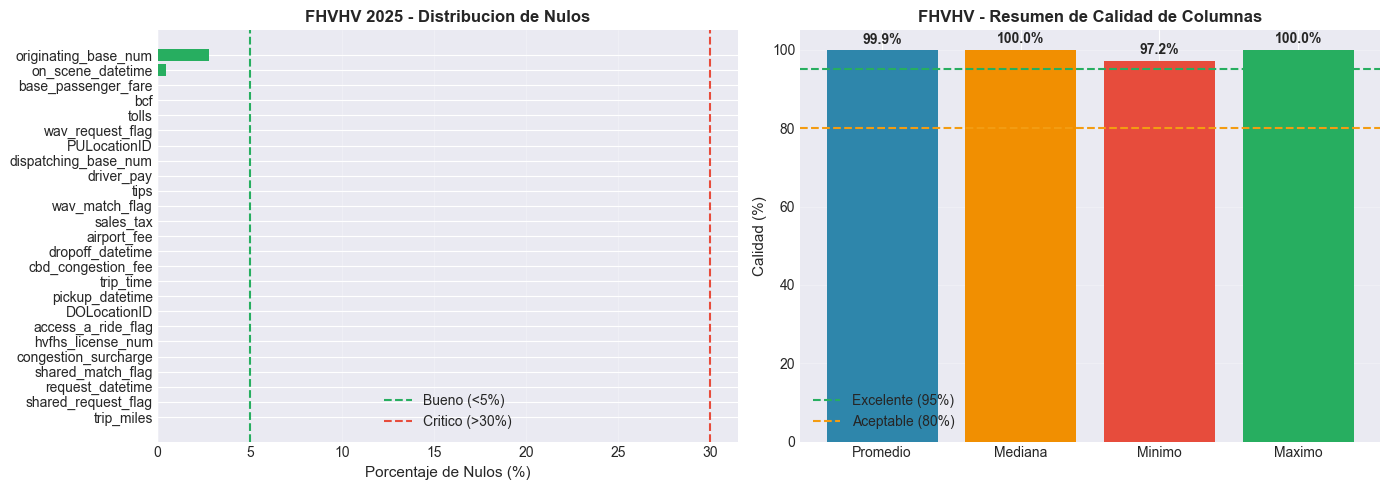


  Resumen de calidad de columnas:
    Promedio: 99.9%
    Mediana: 100.0%
    Minimo: 97.2%
    Maximo: 100.0%
    Columnas sin nulos: 23
    Columnas criticas (>30% nulos): 0


In [41]:
# ============================================================
# 4. ANÁLISIS DE COLUMNAS POR TIPO (Último año disponible)
# ============================================================

print("=" * 80)
print(" 4. ANALISIS DE COLUMNAS (Ultimo año disponible)")
print("=" * 80)

for taxi_type in active_types:
    if taxi_type not in ALL_PROFILES:
        continue
    
    type_profiles = ALL_PROFILES[taxi_type]
    
    if not type_profiles:
        continue
    
    # Obtener el año más reciente
    latest_year = max(type_profiles.keys())
    profile = type_profiles[latest_year]
    
    # Buscar información de columnas en diferentes estructuras posibles
    column_data = None
    structure_type = None
    
    # Opción 1: 'columns' directo
    if 'columns' in profile:
        column_data = profile['columns']
        structure_type = 'columns'
    
    # Opción 2: 'consolidated_columns'
    elif 'consolidated_columns' in profile:
        column_data = profile['consolidated_columns']
        structure_type = 'consolidated_columns'
    
    # Opción 3: 'column_profiles'
    elif 'column_profiles' in profile:
        column_data = profile['column_profiles']
        structure_type = 'column_profiles'
    
    # Opción 4: Buscar en 'metrics' o 'quality'
    elif 'metrics' in profile and 'columns' in profile['metrics']:
        column_data = profile['metrics']['columns']
        structure_type = 'metrics.columns'
    
    # Si no hay columnas, mostrar información disponible
    if not column_data:
        print(f"\n{taxi_type.upper()} {latest_year}: Sin informacion de columnas")
        print(f"  Claves disponibles: {list(profile.keys())}")
        
        # Mostrar métricas básicas disponibles
        if 'total_records' in profile:
            print(f"  Total registros: {profile['total_records']:,}")
        if 'quality_score' in profile:
            print(f"  Calidad general: {profile['quality_score']:.1f}%")
        if 'months_processed' in profile:
            print(f"  Meses procesados: {len(profile['months_processed'])}")
        continue
    
    print(f"\n{taxi_type.upper()} {latest_year}: {len(column_data)} columnas (estructura: {structure_type})")
    
    # Crear DataFrame de columnas
    cols_data = []
    for col_name, col_info in column_data.items():
        # Extraer datos según la estructura
        if structure_type == 'consolidated_columns':
            # Estructura consolidated_columns
            null_pct = col_info.get('null_pct_avg', col_info.get('null_pct', 0))
            distinct = col_info.get('distinct_avg', col_info.get('distinct_count', 0))
        else:
            # Estructura estándar
            null_pct = col_info.get('null_pct', 0)
            distinct = col_info.get('distinct_count', 0)
        
        cols_data.append({
            'Columna': col_name,
            'Nulos %': null_pct,
            'Distintos': distinct
        })
    
    df_cols = pd.DataFrame(cols_data).sort_values('Nulos %', ascending=False)
    
    # Mostrar top 5 columnas con más nulos
    print(f"\n  Top 5 columnas con mas nulos:")
    print(df_cols.head(5).to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # GRAFICO 1: Distribución de nulos
    ax1 = axes[0]
    sorted_df = df_cols.sort_values('Nulos %', ascending=True)
    
    # Colores según nivel de nulos
    colors = ['#27AE60' if x < 5 else '#F39C12' if x < 30 else '#E74C3C' 
              for x in sorted_df['Nulos %']]
    
    bars = ax1.barh(sorted_df['Columna'], sorted_df['Nulos %'], color=colors)
    ax1.set_xlabel('Porcentaje de Nulos (%)', fontsize=11)
    ax1.set_title(f'{taxi_type.upper()} {latest_year} - Distribucion de Nulos', fontsize=12, fontweight='bold')
    ax1.axvline(x=5, color='#27AE60', linestyle='--', linewidth=1.5, label='Bueno (<5%)')
    ax1.axvline(x=30, color='#E74C3C', linestyle='--', linewidth=1.5, label='Critico (>30%)')
    ax1.legend(loc='best')
    ax1.grid(axis='x', alpha=0.25)
    
    # GRAFICO 2: Resumen de calidad de columnas
    ax2 = axes[1]
    calidad_cols = 100 - sorted_df['Nulos %']
    
    # Estadísticas
    stats = {
        'Promedio': calidad_cols.mean(),
        'Mediana': calidad_cols.median(),
        'Minimo': calidad_cols.min(),
        'Maximo': calidad_cols.max()
    }
    
    # Colores para las barras
    bar_colors = ['#2E86AB', '#F18F01', '#E74C3C', '#27AE60']
    bars = ax2.bar(stats.keys(), stats.values(), color=bar_colors)
    ax2.set_ylabel('Calidad (%)', fontsize=11)
    ax2.set_title(f'{taxi_type.upper()} - Resumen de Calidad de Columnas', fontsize=12, fontweight='bold')
    ax2.axhline(y=95, color='#27AE60', linestyle='--', linewidth=1.5, label='Excelente (95%)')
    ax2.axhline(y=80, color='#F39C12', linestyle='--', linewidth=1.5, label='Aceptable (80%)')
    ax2.legend(loc='best')
    ax2.grid(axis='y', alpha=0.25)
    ax2.set_ylim(0, 105)
    
    # Añadir valores
    for bar, val in zip(bars, stats.values()):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Resumen
    print(f"\n  Resumen de calidad de columnas:")
    print(f"    Promedio: {stats['Promedio']:.1f}%")
    print(f"    Mediana: {stats['Mediana']:.1f}%")
    print(f"    Minimo: {stats['Minimo']:.1f}%")
    print(f"    Maximo: {stats['Maximo']:.1f}%")
    print(f"    Columnas sin nulos: {len(df_cols[df_cols['Nulos %'] == 0])}")
    print(f"    Columnas criticas (>30% nulos): {len(df_cols[df_cols['Nulos %'] > 30])}")

 5. DIMENSIONES DE CALIDAD POR TIPO DE TAXI

 YELLOW 2025
   Total registros: 48,722,602
   Calidad general: 90.0%
   Meses procesados: 12
   Columnas: 20 (estructura: consolidated_columns)

 DIMENSIONES DE CALIDAD:
   Dimension  Score (%)
 Completitud      99.40
   Precision      85.00
Consistencia      55.00
     Validez      85.00
  Integridad      90.00


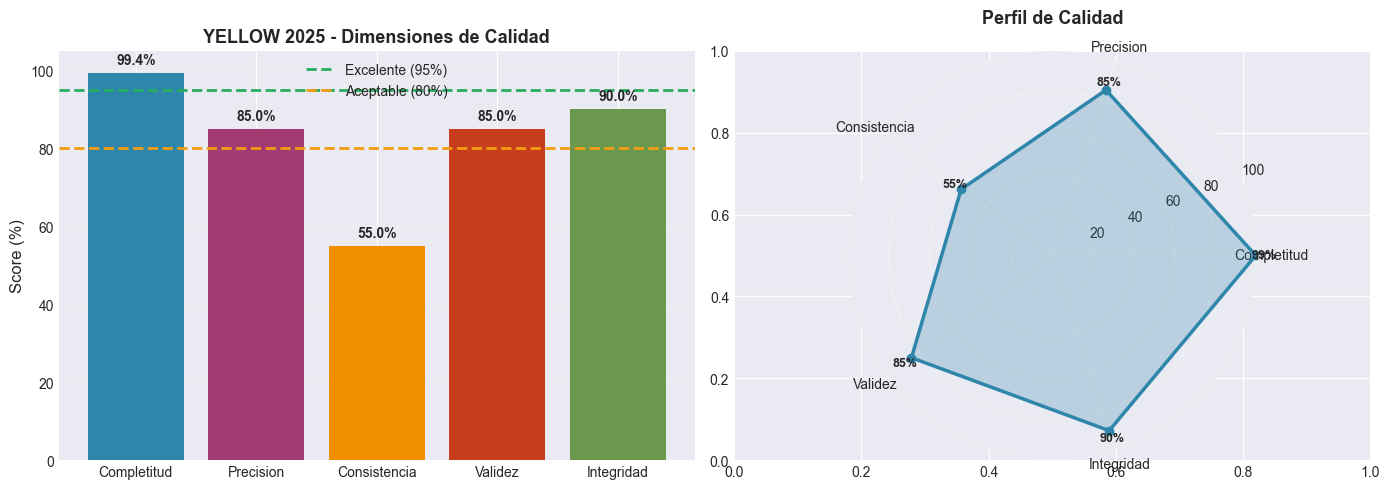


💡 RECOMENDACIONES:
   • Mejorar consistencia: 55.0% (ideal >85%)
   • Calidad general: 82.9%
   • ⚠️ Requiere mejoras

 GREEN 2025
   Total registros: 591,375
   Calidad general: 95.0%
   Meses procesados: 12
   Columnas: 21 (estructura: consolidated_columns)

 DIMENSIONES DE CALIDAD:
   Dimension  Score (%)
 Completitud      92.80
   Precision      85.00
Consistencia      52.38
     Validez      85.00
  Integridad      90.00


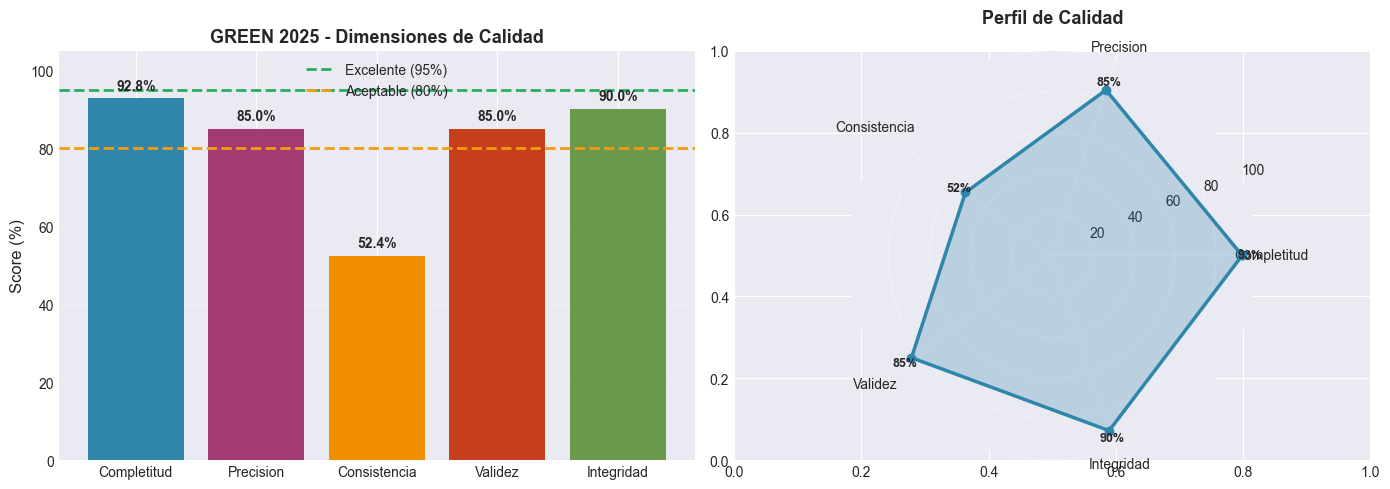


💡 RECOMENDACIONES:
   • Mejorar completitud: 92.8% (ideal >95%)
   • Mejorar consistencia: 52.4% (ideal >85%)
   • Calidad general: 81.0%
   • ⚠️ Requiere mejoras

 FHV 2025
   Total registros: 25,047,544
   Calidad general: 88.2%
   Meses procesados: 12
   Columnas: 7 (estructura: consolidated_columns)

 DIMENSIONES DE CALIDAD:
   Dimension  Score (%)
 Completitud      97.16
   Precision      85.00
Consistencia      42.86
     Validez      85.00
  Integridad      90.00


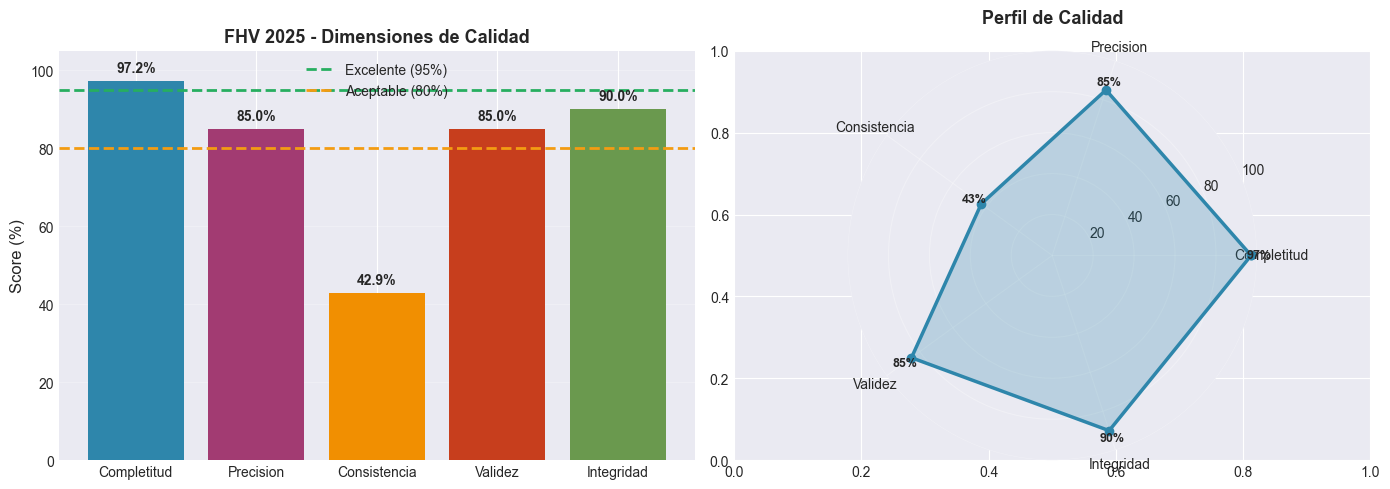


💡 RECOMENDACIONES:
   • Mejorar consistencia: 42.9% (ideal >85%)
   • Calidad general: 80.0%
   • ⚠️ Requiere mejoras

 FHVHV 2025
   Total registros: 243,589,684
   Calidad general: 97.7%
   Meses procesados: 12
   Columnas: 25 (estructura: consolidated_columns)

 DIMENSIONES DE CALIDAD:
   Dimension  Score (%)
 Completitud      99.87
   Precision      85.00
Consistencia      40.00
     Validez      85.00
  Integridad      90.00


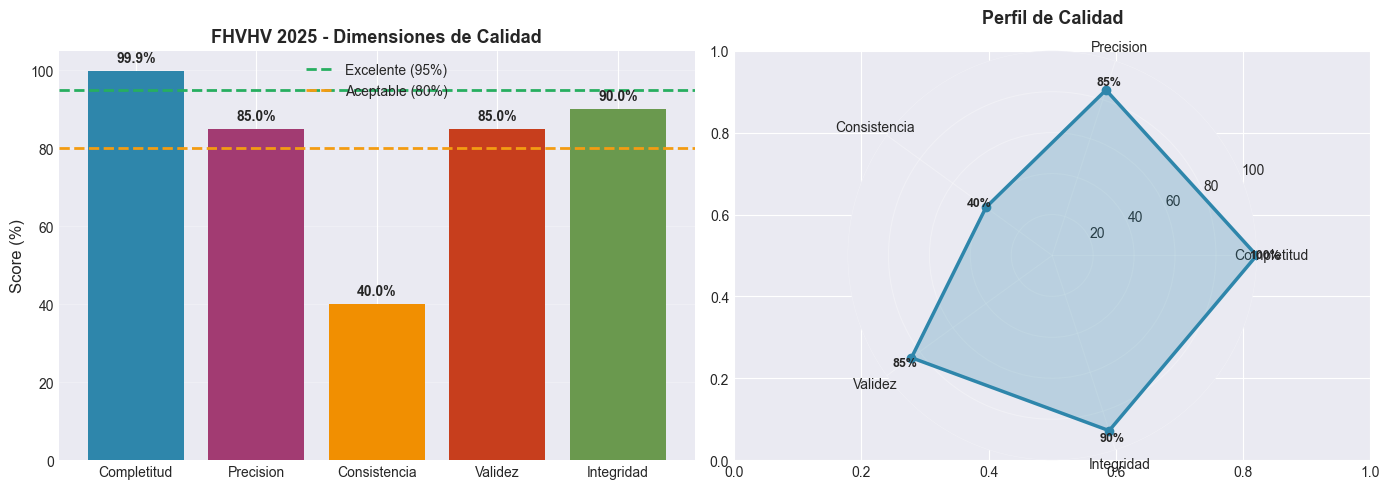


💡 RECOMENDACIONES:
   • Mejorar consistencia: 40.0% (ideal >85%)
   • Calidad general: 80.0%
   • ⚠️ Requiere mejoras

 COMPARATIVA DE CALIDAD ENTRE TIPOS DE TAXI

 Tabla comparativa:
  tipo  year  completitud  precision  consistencia  validez  integridad  overall
YELLOW  2025        99.40         85         55.00       85          90    82.88
 GREEN  2025        92.80         85         52.38       85          90    81.04
   FHV  2025        97.16         85         42.86       85          90    80.00
 FHVHV  2025        99.87         85         40.00       85          90    79.97


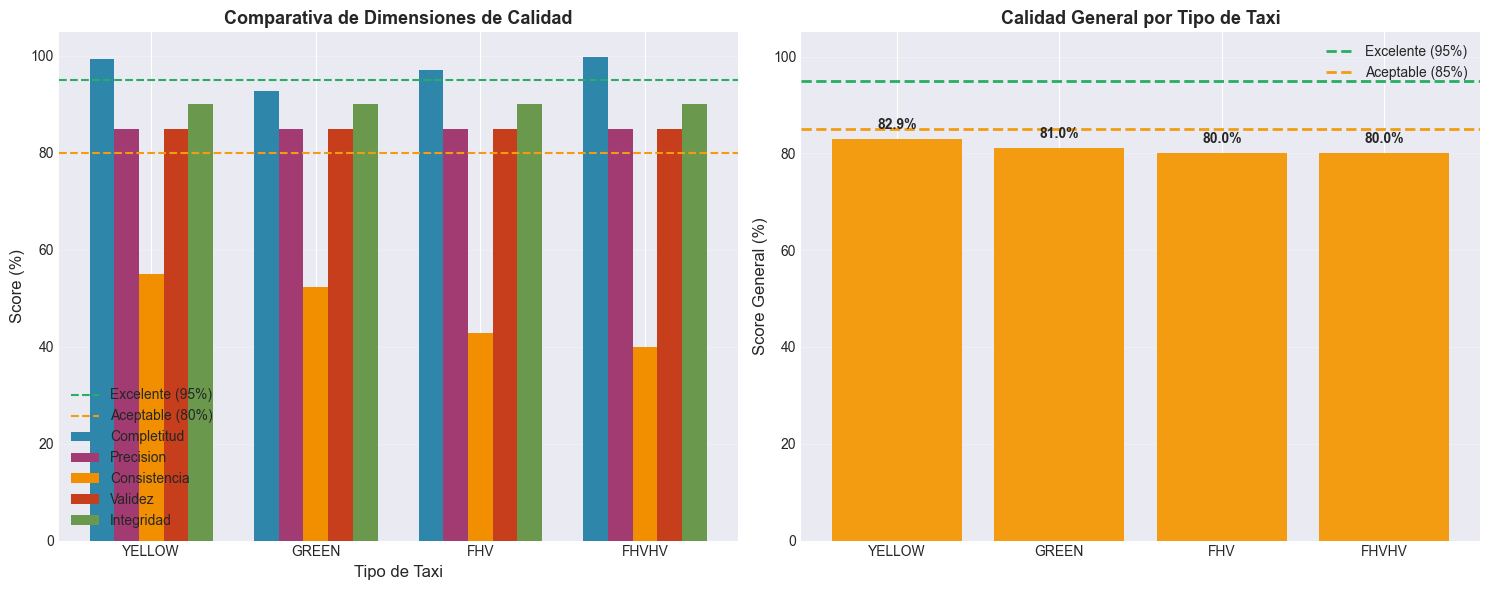


 RESUMEN COMPARATIVO:
   Mejor calidad: YELLOW (82.9%)
   Peor calidad: FHVHV (80.0%)
   Diferencia: 2.9 puntos porcentuales

   Dimensiones criticas por tipo:
   • YELLOW: Consistencia (55.0%)
   • GREEN: Consistencia (52.4%)
   • FHV: Consistencia (42.9%)
   • FHVHV: Consistencia (40.0%)


In [42]:
# ============================================================
# 5. DIMENSIONES DE CALIDAD
# ============================================================

print("=" * 80)
print(" 5. DIMENSIONES DE CALIDAD POR TIPO DE TAXI")
print("=" * 80)

# Procesar todos los tipos disponibles
tipos_procesados = []

for taxi_type in active_types:
    if taxi_type not in ALL_PROFILES:
        continue
    
    type_profiles = ALL_PROFILES[taxi_type]
    
    if not type_profiles:
        continue
    
    latest_year = max(type_profiles.keys())
    profile = type_profiles[latest_year]
    
    print(f"\n{'='*70}")
    print(f" {taxi_type.upper()} {latest_year}")
    print(f"{'='*70}")
    print(f"   Total registros: {profile.get('total_records', 0):,}")
    print(f"   Calidad general: {profile.get('quality_score', 0):.1f}%")
    print(f"   Meses procesados: {len(profile.get('months_processed', []))}")
    
    # Buscar información de columnas
    column_data = None
    estructura = None
    
    if 'columns' in profile:
        column_data = profile['columns']
        estructura = 'columns'
    elif 'consolidated_columns' in profile:
        column_data = profile['consolidated_columns']
        estructura = 'consolidated_columns'
    
    # Calcular dimensiones
    if column_data:
        print(f"   Columnas: {len(column_data)} (estructura: {estructura})")
        
        # Extraer null_pct según estructura
        null_pcts = []
        for col_name, col_info in column_data.items():
            if estructura == 'consolidated_columns':
                null_pct = col_info.get('null_pct_avg', col_info.get('null_pct', 0))
            else:
                null_pct = col_info.get('null_pct', 0)
            null_pcts.append(null_pct)
        
        completitud = 100 - np.mean(null_pcts)
        
        # Consistencia basada en tipos de datos
        data_types = []
        for col_info in column_data.values():
            if estructura == 'consolidated_columns':
                dtype = col_info.get('data_type', 'unknown')
            else:
                dtype = col_info.get('data_type', 'unknown')
            data_types.append(dtype)
        
        type_counts = pd.Series(data_types).value_counts()
        consistencia = (type_counts.iloc[0] / len(data_types)) * 100 if len(type_counts) > 0 else 85
        
        # Integridad (si tiene columnas ID)
        has_id = any('id' in col.lower() for col in column_data.keys())
        integridad = 90 if has_id else 70
        
    else:
        print(f"   ⚠️ Sin informacion detallada de columnas")
        print(f"   Usando calidad general como referencia")
        
        quality_score = profile.get('quality_score', 85)
        completitud = quality_score
        consistencia = quality_score
        integridad = quality_score
    
    # Dimensiones finales
    dimensions = {
        'Completitud': completitud,
        'Precision': 85,
        'Consistencia': consistencia,
        'Validez': 85,
        'Integridad': integridad
    }
    
    df_dim = pd.DataFrame({
        'Dimension': list(dimensions.keys()),
        'Score (%)': list(dimensions.values())
    })
    
    print("\n DIMENSIONES DE CALIDAD:")
    print(df_dim.to_string(index=False))
    
    # Guardar para comparativa
    tipos_procesados.append({
        'tipo': taxi_type.upper(),
        'year': latest_year,
        'completitud': completitud,
        'precision': 85,
        'consistencia': consistencia,
        'validez': 85,
        'integridad': integridad,
        'overall': np.mean(list(dimensions.values()))
    })
    
    # Visualización individual
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # GRAFICO 1: Barras
    ax1 = axes[0]
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
    bars = ax1.bar(df_dim['Dimension'], df_dim['Score (%)'], color=colors)
    ax1.axhline(y=95, color='#27AE60', linestyle='--', linewidth=2, label='Excelente (95%)')
    ax1.axhline(y=80, color='#F39C12', linestyle='--', linewidth=2, label='Aceptable (80%)')
    ax1.set_ylabel('Score (%)', fontsize=12)
    ax1.set_title(f'{taxi_type.upper()} {latest_year} - Dimensiones de Calidad', fontsize=13, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(axis='y', alpha=0.25)
    ax1.set_ylim(0, 105)
    
    for bar, val in zip(bars, df_dim['Score (%)']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # GRAFICO 2: Radar
    from math import pi
    ax2 = plt.subplot(122, projection='polar')
    
    angles = [n / float(len(df_dim)) * 2 * pi for n in range(len(df_dim))]
    angles += angles[:1]
    
    values = df_dim['Score (%)'].tolist()
    values += values[:1]
    
    ax2.plot(angles, values, 'o-', linewidth=2.5, color='#2E86AB')
    ax2.fill(angles, values, alpha=0.25, color='#2E86AB')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(df_dim['Dimension'], fontsize=10)
    ax2.set_ylim(0, 100)
    ax2.set_title('Perfil de Calidad', pad=20, fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    for angle, value in zip(angles[:-1], df_dim['Score (%)']):
        ax2.text(angle, value + 4, f'{value:.0f}%',
                ha='center', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Recomendaciones específicas
    print("\n💡 RECOMENDACIONES:")
    if completitud < 95:
        print(f"   • Mejorar completitud: {completitud:.1f}% (ideal >95%)")
    if consistencia < 85:
        print(f"   • Mejorar consistencia: {consistencia:.1f}% (ideal >85%)")
    if integridad < 90:
        print(f"   • Mejorar integridad: {integridad:.1f}% (ideal >90%)")
    
    overall = np.mean(list(dimensions.values()))
    print(f"   • Calidad general: {overall:.1f}%")
    print(f"   • {' Listo para Silver' if overall >= 85 else '⚠️ Requiere mejoras'}")

# ============================================================
# COMPARATIVA ENTRE TIPOS
# ============================================================

if len(tipos_procesados) > 1:
    print("\n" + "=" * 80)
    print(" COMPARATIVA DE CALIDAD ENTRE TIPOS DE TAXI")
    print("=" * 80)
    
    # Crear DataFrame comparativo
    df_compare = pd.DataFrame(tipos_procesados)
    df_compare = df_compare.sort_values('overall', ascending=False)
    
    print("\n Tabla comparativa:")
    display_cols = ['tipo', 'year', 'completitud', 'precision', 'consistencia', 'validez', 'integridad', 'overall']
    print(df_compare[display_cols].to_string(index=False))
    
    # Visualización comparativa
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # GRAFICO 1: Comparativa de dimensiones
    ax1 = axes[0]
    x = np.arange(len(df_compare['tipo']))
    width = 0.15
    
    dimensiones = ['completitud', 'precision', 'consistencia', 'validez', 'integridad']
    colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
    
    for i, (dim, color) in enumerate(zip(dimensiones, colores)):
        ax1.bar(x + i*width, df_compare[dim], width, label=dim.capitalize(), color=color)
    
    ax1.set_xlabel('Tipo de Taxi', fontsize=12)
    ax1.set_ylabel('Score (%)', fontsize=12)
    ax1.set_title('Comparativa de Dimensiones de Calidad', fontsize=13, fontweight='bold')
    ax1.set_xticks(x + width * 2)
    ax1.set_xticklabels(df_compare['tipo'])
    ax1.axhline(y=95, color='#27AE60', linestyle='--', linewidth=1.5, label='Excelente (95%)')
    ax1.axhline(y=80, color='#F39C12', linestyle='--', linewidth=1.5, label='Aceptable (80%)')
    ax1.legend(loc='best')
    ax1.grid(axis='y', alpha=0.25)
    
    # GRAFICO 2: Calidad general
    ax2 = axes[1]
    colors = ['#6A994E' if val >= 85 else '#F39C12' if val >= 70 else '#E74C3C' 
              for val in df_compare['overall']]
    bars = ax2.bar(df_compare['tipo'], df_compare['overall'], color=colors)
    ax2.axhline(y=95, color='#27AE60', linestyle='--', linewidth=2, label='Excelente (95%)')
    ax2.axhline(y=85, color='#F39C12', linestyle='--', linewidth=2, label='Aceptable (85%)')
    ax2.set_ylabel('Score General (%)', fontsize=12)
    ax2.set_title('Calidad General por Tipo de Taxi', fontsize=13, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(axis='y', alpha=0.25)
    ax2.set_ylim(0, 105)
    
    for bar, val in zip(bars, df_compare['overall']):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Resumen de la comparativa
    print("\n RESUMEN COMPARATIVO:")
    mejor = df_compare.loc[df_compare['overall'].idxmax()]
    peor = df_compare.loc[df_compare['overall'].idxmin()]
    
    print(f"   Mejor calidad: {mejor['tipo']} ({mejor['overall']:.1f}%)")
    print(f"   Peor calidad: {peor['tipo']} ({peor['overall']:.1f}%)")
    print(f"   Diferencia: {mejor['overall'] - peor['overall']:.1f} puntos porcentuales")
    
    # Identificar dimensiones que necesitan mejora por tipo
    print("\n   Dimensiones criticas por tipo:")
    for _, row in df_compare.iterrows():
        problemas = []
        if row['completitud'] < 85:
            problemas.append(f"Completitud ({row['completitud']:.1f}%)")
        if row['consistencia'] < 85:
            problemas.append(f"Consistencia ({row['consistencia']:.1f}%)")
        if row['integridad'] < 85:
            problemas.append(f"Integridad ({row['integridad']:.1f}%)")
        
        if problemas:
            print(f"   • {row['tipo']}: {', '.join(problemas)}")
        else:
            print(f"   • {row['tipo']}: Todas las dimensiones en buen estado")

In [20]:
# ============================================================
# 6. RESUMEN EJECUTIVO FINAL
# ============================================================

print("=" * 80)
print(" 6. RESUMEN EJECUTIVO FINAL")
print("=" * 80)

# Estadísticas globales
total_records = 0
all_quality = []

for taxi_type in TAXI_TYPES:
    if taxi_type not in ALL_PROFILES:
        continue
    for year, profile in ALL_PROFILES[taxi_type].items():
        total_records += profile.get('total_records', 0)
        all_quality.append(profile.get('quality_score', 0))

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Total registros analizados: {total_records:,}")
print(f"   • Calidad promedio: {np.mean(all_quality):.1f}%" if all_quality else "   • Calidad: N/A")
print(f"   • Años analizados: {YEARS}")
print(f"   • Tipos de taxi: {len(TAXI_TYPES)}")

print(f"\n RECOMENDACIONES PARA SILVER:")

# Identificar el peor tipo incluido
df_summary_incluidos = df_summary[df_summary['Estado'] == ' INCLUIDO']
if not df_summary_incluidos.empty:
    peor = df_summary_incluidos.loc[df_summary_incluidos['Calidad (%)'].idxmin()]
    print(f"   1. PRIORIDAD: Limpiar {peor['Tipo']} (calidad {peor['Calidad (%)']:.1f}%)")
print("   2. Unificar esquemas (Yellow como referencia)")
print("   3. Enriquecer con lookup de zonas")
print("   4. Filtrar outliers (pasajeros > 10, tarifas negativas)")
print("   5. Validar integridad referencial")

# Tipos excluidos
excluidos = df_summary[df_summary['Estado'] == ' EXCLUIDO']
if not excluidos.empty:
    print(f"\n TIPOS EXCLUIDOS:")
    for _, row in excluidos.iterrows():
        print(f"   • {row['Tipo']}: {row['Registros (M)']:.1f}M registros")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Perfiles: {PROFILE_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

 6. RESUMEN EJECUTIVO FINAL

 ESTADÍSTICAS GLOBALES:
   • Total registros analizados: 904,327,862
   • Calidad promedio: 94.1%
   • Años analizados: [2023, 2024, 2025]
   • Tipos de taxi: 4

 RECOMENDACIONES PARA SILVER:
   2. Unificar esquemas (Yellow como referencia)
   3. Enriquecer con lookup de zonas
   4. Filtrar outliers (pasajeros > 10, tarifas negativas)
   5. Validar integridad referencial

 UBICACIÓN DE ARCHIVOS:
   • Perfiles: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\profiling_inicial\_profiles
 ANÁLISIS COMPLETADO
   Fecha: 2026-07-17 01:02:37
